<a href="https://colab.research.google.com/github/shashankshekhar28/fashion-product-classification/blob/main/fashion_product_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/archive (2)')

In [ ]:
import pandas as pd
df=pd.read_csv("/content/archive (2)/data.csv")
df.head()

,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes


In [ ]:
a=df['category'].value_counts()
a

,count
category,
Tshirts,7069
Shirts,3215
Casual Shoes,2846
Watches,2542
Sports Shoes,2036
...,...
Cushion Covers,1
Hair Accessory,1
Body Wash and Scrub,1


In [ ]:
counts = df['category'].value_counts()
counts[counts > 500]

,count
category,
Tshirts,7069
Shirts,3215
Casual Shoes,2846
Watches,2542
Sports Shoes,2036
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


In [ ]:
valid_categories = counts[counts > 500].index
df_filtered = df[df['category'].isin(valid_categories)]
df_filtered['category'].value_counts()

,count
category,
Tshirts,7069
Shirts,3215
Casual Shoes,2846
Watches,2542
Sports Shoes,2036
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


In [ ]:
#downsampling data to 530 images in each category
balanced_df = (
    df_filtered
    .groupby('category', group_keys=False)
    .apply(lambda x: x.sample(n=530, random_state=42))
)

/tmp/ipykernel_9025/339973060.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=530, random_state=42))


In [ ]:
balanced_df.shape

(11660, 4)

In [ ]:
#shuffliing dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
balanced_df.head()

,image,description,display name,category
0,56882.jpg,"Heel: 2.5"" Open toe heels with a forefoot and ...",HM Women Red Heels,Heels
1,33647.jpg,The luxe comfort and rugged styling of lotto's...,Lotto Men Ridge Black Sandals,Sandals
2,41513.jpg,Style Note Wear these fashion forward and tren...,Basics Men Aviator Sunglasses 10BSG24309,Sunglasses
3,42865.jpg,Style Note This french connection piece nails ...,French Connection Women Black Dorris Handbag,Handbags
4,19797.jpg,"Composition Grey polo t-shirt with red,blue an...",U.S. Polo Assn. Men Striped Grey T-shirt,Tshirts


In [ ]:
#splitting the dataset now
from sklearn.model_selection import train_test_split

#making train 80% and test 20%
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['category'],
    random_state=42
)
#making validation from test set
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['category'],
    random_state=42
)

In [ ]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

9328
1166
1166


In [ ]:
train_df['category'].value_counts()
#to check every count

,count
category,
Tshirts,424
Sports Shoes,424
Jeans,424
Trousers,424
Wallets,424
Handbags,424
Tops,424
Sandals,424
Briefs,424


In [ ]:
!pip install transformers==4.37.2 torch

In [ ]:
#we have enabled GPU and mixed precision for faster training
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
#importing required libraries
import pandas as pd
import numpy as np
import os
import torch

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Concatenate,
    Multiply,
    Lambda
)

from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

from transformers import DistilBertTokenizer, DistilBertModel

In [ ]:
#Combine Text Columns
train_df["text"] = train_df["display name"] + " " + train_df["description"]
val_df["text"] = val_df["display name"] + " " + val_df["description"]
test_df["text"] = test_df["display name"] + " " + test_df["description"]

In [ ]:
train_df["text"].apply(type).value_counts()
#since some of the text was float,we used below code to convert them to string

,count
text,
<class 'str'>,9245
<class 'float'>,83


In [ ]:
#converting them to string
train_df["text"] = train_df["text"].fillna("").astype(str)
val_df["text"] = val_df["text"].fillna("").astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

In [ ]:
#encoding all labels or categories

le = LabelEncoder()

train_df["label"] = le.fit_transform(train_df["category"])
val_df["label"] = le.transform(val_df["category"])
test_df["label"] = le.transform(test_df["category"])

num_classes = len(le.classes_)

In [ ]:
train_df.head()

,image,description,display name,category,text,label
1519,9991.jpg,"Blue and green striped polo t-shirt, made of 1...",Nike Men As Ad Club Pi Blue T-Shirts,Tshirts,Nike Men As Ad Club Pi Blue T-Shirts Blue and ...,19
6595,5749.jpg,These hi-tech reebok Hex Run shoes are designe...,Reebok Men's Hex Run White Shoe,Sports Shoes,Reebok Men's Hex Run White Shoe These hi-tech ...,15
3986,9163.jpg,Composition Faded blue jeans made of 100% cott...,Locomotive Men Cael Blue Jeans,Jeans,Locomotive Men Cael Blue Jeans Composition Fad...,8
9554,54194.jpg,"Grey twill weave chinos, has two slant pockets...",Highlander Men Grey Chinos,Trousers,Highlander Men Grey Chinos Grey twill weave ch...,18
9057,41263.jpg,"Style Note Crafted from finest quality, these ...",Arrow Men Black Wallet,Wallets,Arrow Men Black Wallet Style Note Crafted from...,20


In [ ]:
#loading and using BERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")

distilbert.eval()

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
distilbert.to(device)

In [ ]:
#precompute text embeddings(batched)
def compute_embeddings(texts, batch_size=64):

    embeddings = []

    texts = texts.fillna("").astype(str).tolist()

    total = len(texts)

    for i in range(0, total, batch_size):

        if i % 640 == 0:
            print(f"Processed {i}/{total}")

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():

            outputs = distilbert(**inputs)

        batch_embed = outputs.last_hidden_state[:,0,:]

        batch_embed = batch_embed.cpu().numpy()

        embeddings.append(batch_embed)

    embeddings = np.vstack(embeddings)

    return embeddings

In [ ]:
#computing embeddings for each split
train_text_embed = compute_embeddings(train_df["text"])
val_text_embed = compute_embeddings(val_df["text"])
test_text_embed = compute_embeddings(test_df["text"])

Processed 0/9328
Processed 640/9328
Processed 1280/9328
Processed 1920/9328
Processed 2560/9328
Processed 3200/9328
Processed 3840/9328
Processed 4480/9328
Processed 5120/9328
Processed 5760/9328
Processed 6400/9328
Processed 7040/9328
Processed 7680/9328
Processed 8320/9328
Processed 8960/9328
Processed 0/1166
Processed 640/1166
Processed 0/1166
Processed 640/1166


In [ ]:
print(train_text_embed.shape)
print(val_text_embed.shape)
print(test_text_embed.shape)

(9328, 768)
(1166, 768)
(1166, 768)


In [ ]:
#normalize text embeddings
train_text_embed = train_text_embed / np.linalg.norm(train_text_embed, axis=1, keepdims=True)
val_text_embed = val_text_embed / np.linalg.norm(val_text_embed, axis=1, keepdims=True)
test_text_embed = test_text_embed / np.linalg.norm(test_text_embed, axis=1, keepdims=True)

In [ ]:
#IMAGE LOADING PART
IMG_SIZE = 224
img_dir = "/content/archive (2)/data"

def load_image(filename):

    path = tf.strings.join([img_dir, "/", filename])

    img = tf.io.read_file(path)

    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    return img

In [ ]:
#tf.data Dataset
def create_dataset(df, text_embeddings):

    image_files = df["image"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_files, text_embeddings, labels)
    )

    def process(image_file, text_embed, label):

        img = load_image(image_file)

        return (
            {
                "image_input": img,
                "text_input": text_embed
            },
            label
        )

    dataset = dataset.map(process, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.shuffle(1000)

    dataset = dataset.batch(16)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
#create datasets
train_dataset = create_dataset(train_df, train_text_embed)
val_dataset = create_dataset(val_df, val_text_embed)
test_dataset = create_dataset(test_df, test_text_embed)

In [ ]:
#Image augmentation part
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [ ]:
#Image encoder(MobileNetV2)
image_input = Input(shape=(224,224,3), name="image_input")

augmented = data_augmentation(image_input)

cnn_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=augmented
)

/tmp/ipykernel_9025/3989594268.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn_base = MobileNetV2(


In [ ]:
cnn_base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ sequential_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
#freezing trainable layers layers
for layer in cnn_base.layers:
    layer.trainable = False

In [ ]:
cnn_base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ sequential_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#image embedding
x = cnn_base.output
x = GlobalAveragePooling2D()(x)
image_features = Dense(256, activation="relu")(x)

In [ ]:
#text encoder
text_input = Input(shape=(768,), name="text_input")
text_features = Dense(256, activation="relu")(text_input)

In [ ]:
#GATED MULTIMODAL FUSION
fusion = Concatenate()([image_features, text_features])

gate = Dense(256, activation="sigmoid")(fusion)

gated_image = Multiply()([image_features, gate])

gated_text = Multiply()([text_features, gate])

fused = Concatenate()([gated_image, gated_text])

In [ ]:
#classification head of GMF
x = Dense(256, activation="relu")(fused)
x = Dense(128, activation="relu")(x)

output = Dense(num_classes, activation="softmax", dtype="float32")(x)

In [ ]:
#model Building
model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

In [ ]:
#compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
#training the model
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
583/583 ━━━━━━━━━━━━━━━━━━━━ 75s 126ms/step - accuracy: 0.7379 - loss: 0.9830 - val_accuracy: 0.8954 - val_loss: 0.3592
Epoch 2/5
583/583 ━━━━━━━━━━━━━━━━━━━━ 46s 63ms/step - accuracy: 0.8849 - loss: 0.3436 - val_accuracy: 0.9031 - val_loss: 0.3156
Epoch 3/5
583/583 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.9059 - loss: 0.2794 - val_accuracy: 0.9134 - val_loss: 0.2638
Epoch 4/5
583/583 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.9199 - loss: 0.2385 - val_accuracy: 0.9237 - val_loss: 0.2581
Epoch 5/5
583/583 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.9319 - loss: 0.2054 - val_accuracy: 0.9245 - val_loss: 0.2429


In [ ]:
model.evaluate(test_dataset)

73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9211 - loss: 0.2182


[0.21821530163288116, 0.9210977554321289]

In [ ]:
# DEMO TIMEE

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving school-backpack-isolated-illustration-ai-generative-free-photo.jpg to school-backpack-isolated-illustration-ai-generative-free-photo.jpg


In [ ]:
img_path = list(uploaded.keys())[0]

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

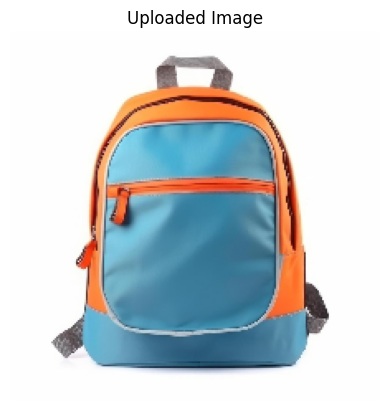

In [ ]:
#displaying uploaded image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

IMG_SIZE = 224

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")

In [ ]:
text = input("Enter product description: ")

Enter product description: blue


In [ ]:
#converting text to DeliBERT embedding
inputs = tokenizer(
    [text],
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

inputs = {k:v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    outputs = distilbert(**inputs)

text_embed = outputs.last_hidden_state[:,0,:]

text_embed = text_embed.cpu().numpy()

In [ ]:
#normalizing the text same as in training
text_embed = text_embed / np.linalg.norm(text_embed, axis=1, keepdims=True)

In [ ]:
#Predict Category
prediction = model.predict({
    "image_input": img_array,
    "text_input": text_embed
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [ ]:
#showing category
pred_class = np.argmax(prediction)
predicted_category = le.inverse_transform([pred_class])[0]

print("Predicted Category:", predicted_category)

Predicted Category: Backpacks


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

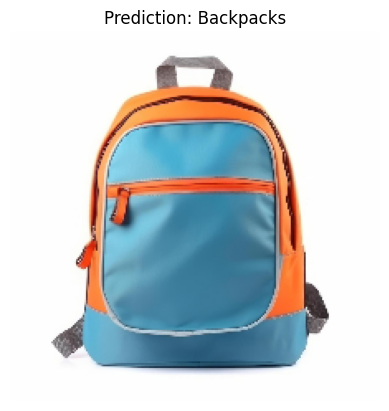

In [ ]:
#final prediction with image
plt.imshow(img)
plt.title(f"Prediction: {predicted_category}")
plt.axis("off")